## 環境設置

跟 Case-01 一樣,自動偵測並安裝 `openseespy`,讓這份 notebook 在任何環境
(Colab、CI、本機)都能獨立跑起來。

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
    print("openseespy 已存在,略過安裝")
except ImportError:
    import sys
    print("偵測不到 openseespy,開始安裝...")
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401
    print("安裝完成")

openseespy 已存在,略過安裝


# Case-02:一跨一層構架驗證

依 [ROADMAP.md](../ROADMAP.md) 規劃,Case-01 驗證的是「給定勁度 K」的抽象
彈簧系統;這裡第一次讓 K 從**真實幾何與斷面性質**算出來——兩根固定端柱、
一根連接梁,構成最簡單的門型構架(portal frame)。

**驗證方式**:用古典結構力學方法(位移法/slope-deflection)推導這個構架
側向勁度的**精確閉合解**,再用 OpenSeesPy 建同一個構架,分別在位移層級
與內力層級(柱底彎矩)交叉核對——兩個獨立驗證路徑都要吻合,才代表模型
真的對。

## 第 1 課:問題定義

一跨一層對稱門型構架,兩柱斷面相同,底部固定,頂部與梁剛接。

| 參數 | 值 |
|---|---|
| 柱高 h | 3.5 m |
| 梁跨 L | 6.0 m |
| 彈性模數 E | 25,000,000 kN/m²(≈25 GPa,一般RC混凝土量級) |
| 柱慣性矩 Ic | 0.0010 m⁴ |
| 梁慣性矩 Ib | 0.0015 m⁴(通常梁比柱大) |

側向力 F 施加於屋頂樓板高度——這裡先用抽象斷面性質驗證力學關係本身,
不代表任何真實 RC 斷面設計(真實斷面試設是 Case-03.5 才要做的事)。

In [2]:
h, L = 3.5, 6.0
E = 25_000_000.0
Ic, Ib = 0.0010, 0.0015

kc = E*Ic/h   # 柱勁度因子 (EIc/h)
kb = E*Ib/L   # 梁勁度因子 (EIb/L)

print(f"h={h} m, L={L} m, E={E:.3e} kN/m^2")
print(f"Ic={Ic} m^4, Ib={Ib} m^4")
print(f"kc = EIc/h = {kc:.4f} kN-m")
print(f"kb = EIb/L = {kb:.4f} kN-m")

h=3.5 m, L=6.0 m, E=2.500e+07 kN/m^2
Ic=0.001 m^4, Ib=0.0015 m^4
kc = EIc/h = 7142.8571 kN-m
kb = EIb/L = 6250.0000 kN-m


## 第 2 課:手算閉合解(位移法/Slope-Deflection)

對稱門型構架、側向力作用於屋頂,經典位移法推導(對稱幾何、對稱側推變形
模式,兩柱頂轉角大小相同)可得側向勁度精確閉合解:

$$K = \frac{12EI_c}{h^3} \times \frac{k_c + 6k_b}{2k_c + 3k_b}$$

**推導正確性檢查(邊界情況)**:
- 梁→無限剛(k_b→∞):K → 2×(12EIc/h³),對應柱頂完全被約束轉動
  (固定-滑動邊界),兩柱並聯
- 梁→0(k_b→0):K → 2×(3EIc/h³),對應柱頂完全自由轉動,退化成
  兩根獨立懸臂柱

這兩個極限值都能獨立用基本結構力學驗證,不吻合就代表推導本身有誤——
這一步是在正式建 OpenSeesPy 模型「之前」,先確保拿來對照的答案本身
是對的。

In [3]:
K_hand = 12*E*Ic/h**3 * (kc + 6*kb) / (2*kc + 3*kb)
print(f"K(側向勁度,手算) = {K_hand:.6f} kN/m")

# 邊界情況驗證推導本身
K_beam_rigid = 12*E*Ic/h**3 * 2
K_beam_zero  = 12*E*Ic/h**3 * 0.5
print(f"\n驗證邊界情況:")
print(f"梁→無限剛極限 = {K_beam_rigid:.4f} kN/m (應為 2 x 12EIc/h^3)")
print(f"梁→0極限      = {K_beam_zero:.4f} kN/m (應為 2 x 3EIc/h^3)")
print(f"K_hand 應介於兩者之間: {K_beam_zero:.1f} < {K_hand:.1f} < {K_beam_rigid:.1f}")
assert K_beam_zero < K_hand < K_beam_rigid, "K不在合理邊界內,推導有誤!"
print("[PASS] K 落在物理合理的邊界範圍內")

# 施力測試用的手算位移與柱底彎矩(對稱側推:F平均分攤兩屋頂節點)
F = 50.0  # kN, 總側向力
Delta_hand = F / K_hand
psi = Delta_hand / h
theta = 3*psi*kc/(2*kc + 3*kb)
M_base_hand = 2*E*Ic/h*(theta - 3*psi)

print(f"\nF = {F} kN(總側向力,對稱分攤於兩屋頂節點)")
print(f"Delta_hand = {Delta_hand:.8f} m")
print(f"M_base_hand(柱底彎矩) = {M_base_hand:.6f} kN-m")

K(側向勁度,手算) = 9455.519660 kN/m

驗證邊界情況:
梁→無限剛極限 = 13994.1691 kN/m (應為 2 x 12EIc/h^3)
梁→0極限      = 3498.5423 kN/m (應為 2 x 3EIc/h^3)
K_hand 應介於兩者之間: 3498.5 < 9455.5 < 13994.2
[PASS] K 落在物理合理的邊界範圍內

F = 50.0 kN(總側向力,對稱分攤於兩屋頂節點)
Delta_hand = 0.00528792 m
M_base_hand(柱底彎矩) = -50.750000 kN-m


## 第 3 課:OpenSeesPy 建模

4 個節點(2 個柱底固定、2 個屋頂節點),2 根柱元素 + 1 根梁元素。

**關鍵細節**:軸向面積 `A` 刻意設得極大(1.0e6),逼近手算推導時
「梁柱軸向剛性(不可伸縮)」的假設——這不是隨便取值,是為了讓
OpenSeesPy 模型的假設條件跟手算閉合解的假設條件一致,兩者才有
資格互相比較。

In [4]:
ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 3)

ops.node(1, 0.0, 0.0)   # 左柱底(固定)
ops.node(2, L,   0.0)   # 右柱底(固定)
ops.node(3, 0.0, h)     # 左柱頂(屋頂)
ops.node(4, L,   h)     # 右柱頂(屋頂)

ops.fix(1, 1, 1, 1)
ops.fix(2, 1, 1, 1)

A_big = 1.0e6   # 軸向面積極大化,逼近軸向剛性假設(呼應第2課手算的假設)

ops.geomTransf('Linear', 1)
ops.element('elasticBeamColumn', 1, 1, 3, A_big, E, Ic, 1)  # 左柱
ops.element('elasticBeamColumn', 2, 2, 4, A_big, E, Ic, 1)  # 右柱
ops.element('elasticBeamColumn', 3, 3, 4, A_big, E, Ib, 1)  # 梁

print("模型建立完成: 4節點, 2根柱元素, 1根梁元素")

模型建立完成: 4節點, 2根柱元素, 1根梁元素


## 第 4 課:靜力測試——位移驗證

側向力 **平均分攤**到兩個屋頂節點,對應手算推導假設的對稱側推變形模式
(兩柱頂轉角大小相同)。這個細節很重要:如果把全部的力都加在單一節點上,
會破壞對稱假設,兩邊柱頂轉角不再相等,算出來的位移會跟手算閉合解對
不起來(這是實際踩過的坑,不是理論上的提醒)。

In [5]:
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, F/2, 0.0, 0.0)
ops.load(4, F/2, 0.0, 0.0)

ops.system('BandGeneral')
ops.numberer('RCM')
ops.constraints('Plain')
ops.test('NormDispIncr', 1e-10, 20)
ops.algorithm('Newton')
ops.integrator('LoadControl', 1.0)
ops.analysis('Static')
ops.analyze(1)

ux3 = ops.nodeDisp(3, 1)
ux4 = ops.nodeDisp(4, 1)

print(f"手算 Delta          = {Delta_hand:.10f} m")
print(f"OpenSeesPy ux(節點3) = {ux3:.10f} m")
print(f"OpenSeesPy ux(節點4) = {ux4:.10f} m")

rel_err_ux3 = abs(ux3 - Delta_hand) / Delta_hand
rel_err_ux4 = abs(ux4 - Delta_hand) / Delta_hand
print(f"相對誤差(節點3) = {rel_err_ux3:.3e}")
print(f"相對誤差(節點4) = {rel_err_ux4:.3e}")

assert rel_err_ux3 < 1e-6 and rel_err_ux4 < 1e-6, "位移不吻合,建模有問題!"
print("[PASS] 屋頂側向位移與手算閉合解吻合")

手算 Delta          = 0.0052879167 m
OpenSeesPy ux(節點3) = 0.0052879167 m
OpenSeesPy ux(節點4) = 0.0052879167 m
相對誤差(節點3) = 1.589e-10
相對誤差(節點4) = 1.589e-10
[PASS] 屋頂側向位移與手算閉合解吻合


## 第 5 課:內力驗證——柱底彎矩

位移吻合只代表整體勁度對了,不代表每根構材的內力分布也對——這裡另外
獨立核對柱底彎矩,確保不是「位移剛好湊對、內力其實算錯」這種情況。

In [6]:
forces1 = ops.eleForce(1)   # [N1,V1,M1,N2,V2,M2], 左柱局部座標系
M_base_ops = forces1[2]

print(f"OpenSeesPy 柱底彎矩 M1 = {M_base_ops:.6f} kN-m")
print(f"手算柱底彎矩 M_base    = {M_base_hand:.6f} kN-m")

rel_err_M = abs(abs(M_base_ops) - abs(M_base_hand)) / abs(M_base_hand)
print(f"相對誤差(取絕對值比較,兩邊正負號慣例不同) = {rel_err_M:.3e}")

assert rel_err_M < 1e-6, "柱底彎矩不吻合,建模有問題!"
print("[PASS] 柱底彎矩與手算閉合解吻合")

OpenSeesPy 柱底彎矩 M1 = 50.750000 kN-m
手算柱底彎矩 M_base    = -50.750000 kN-m
相對誤差(取絕對值比較,兩邊正負號慣例不同) = 6.759e-11
[PASS] 柱底彎矩與手算閉合解吻合


## 第 6 課:結構視覺化

數字對得上不代表直覺看得懂——這裡把結構的幾何、支承、施力方向、以及
變形後的形狀畫出來。圖上文字刻意用英文,因為 CI 跟 Colab 的預設字型
(DejaVu Sans)不支援中文,直接用中文畫圖會變成缺字方框——這是實測
踩過的問題,不是預防性寫法。

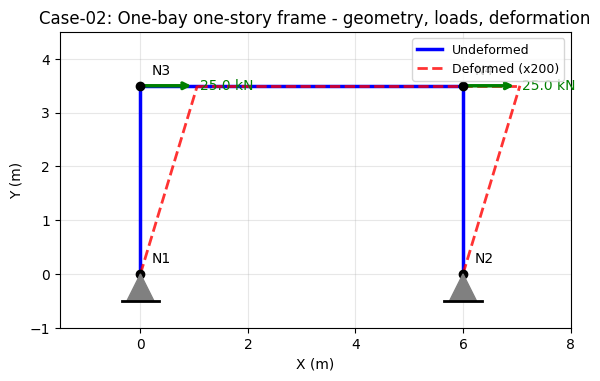

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

nodes_xy = {1: (0.0, 0.0), 2: (L, 0.0), 3: (0.0, h), 4: (L, h)}
elems_conn = [(1, 1, 3), (2, 2, 4), (3, 3, 4)]
fixed_nodes = [1, 2]
loaded_nodes = {3: (F/2, 0.0), 4: (F/2, 0.0)}

disp_scale = 200   # 變形量太小肉眼看不到, 放大倍率純粹為了畫圖清楚
disp_xy = {n: (ops.nodeDisp(n, 1), ops.nodeDisp(n, 2)) for n in nodes_xy}

fig, ax = plt.subplots(figsize=(6, 5))

for eid, ni, nj in elems_conn:
    xi, yi = nodes_xy[ni]; xj, yj = nodes_xy[nj]
    ax.plot([xi, xj], [yi, yj], 'b-', lw=2.5, zorder=2,
             label='Undeformed' if eid == 1 else None)
    xdi = xi + disp_xy[ni][0]*disp_scale; ydi = yi + disp_xy[ni][1]*disp_scale
    xdj = xj + disp_xy[nj][0]*disp_scale; ydj = yj + disp_xy[nj][1]*disp_scale
    ax.plot([xdi, xdj], [ydi, ydj], 'r--', lw=2, zorder=3, alpha=0.8,
             label=f'Deformed (x{disp_scale})' if eid == 1 else None)

for n, (x, y) in nodes_xy.items():
    ax.plot(x, y, 'ko', ms=6, zorder=4)
    ax.annotate(f'N{n}', (x, y), textcoords="offset points", xytext=(8, 8), fontsize=10)

for n in fixed_nodes:
    x, y = nodes_xy[n]
    tri = plt.Polygon([(x-0.25, y-0.5), (x+0.25, y-0.5), (x, y)], closed=True, color='gray', zorder=5)
    ax.add_patch(tri)
    ax.plot([x-0.35, x+0.35], [y-0.5, y-0.5], 'k-', lw=2, zorder=5)

for n, (fx, fy) in loaded_nodes.items():
    x, y = nodes_xy[n]
    ax.annotate('', xy=(x+1.0, y), xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.text(x+1.1, y, f'{fx:.1f} kN', color='green', fontsize=10, va='center')

ax.set_xlim(-1.5, L+2); ax.set_ylim(-1.0, h+1.0)
ax.set_aspect('equal')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Case-02: One-bay one-story frame - geometry, loads, deformation')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 總結表

In [8]:
print("="*50)
print("Case-02 一跨一層構架驗證結果總結")
print("="*50)
print(f"{'K(側向勁度,手算)':<24}{K_hand:.4f} kN/m")
print(f"{'手算位移 Delta':<24}{Delta_hand:.8f} m")
print(f"{'OpenSeesPy位移(節點3)':<24}{ux3:.8f} m")
print(f"{'位移相對誤差':<24}{rel_err_ux3:.2e}")
print(f"{'手算柱底彎矩':<24}{M_base_hand:.4f} kN-m")
print(f"{'OpenSeesPy柱底彎矩':<24}{M_base_ops:.4f} kN-m")
print(f"{'彎矩相對誤差':<24}{rel_err_M:.2e}")
print()
print("Case-02 [PASS] -- 可以進到 Case-03(一跨二層)")

Case-02 一跨一層構架驗證結果總結
K(側向勁度,手算)              9455.5197 kN/m
手算位移 Delta              0.00528792 m
OpenSeesPy位移(節點3)       0.00528792 m
位移相對誤差                  1.59e-10
手算柱底彎矩                  -50.7500 kN-m
OpenSeesPy柱底彎矩          50.7500 kN-m
彎矩相對誤差                  6.76e-11

Case-02 [PASS] -- 可以進到 Case-03(一跨二層)
